In [1]:
import numpy as np
import pandas as pd
import scipy.stats as sps
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
N = 1_000
M = 200
rng = np.random.default_rng(1234567)
X = rng.multivariate_normal(np.zeros(M), np.eye(M), size=N)

In [3]:
X.shape

(1000, 200)

In [4]:
rho = np.zeros((M, M))
p = np.zeros((M, M))
for i in range(M):
    for j in range(M):
        rho[i,j], p[i,j] = list(sps.pearsonr(X[:,i], X[:,j]))
tril_mask = np.tri(N=M, k=-1)

<Axes: >

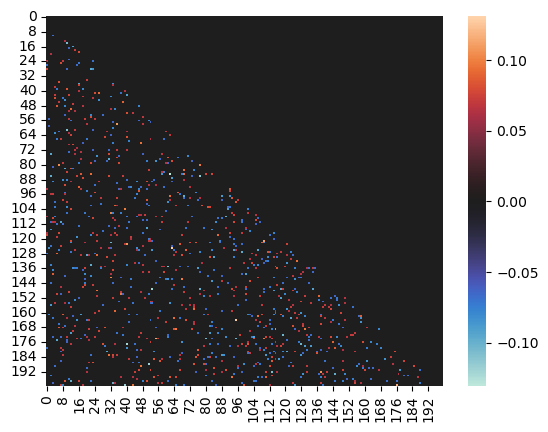

In [5]:
sns.heatmap(rho * (p < 0.05) * (tril_mask == 1), center=0.0)

<Axes: ylabel='Count'>

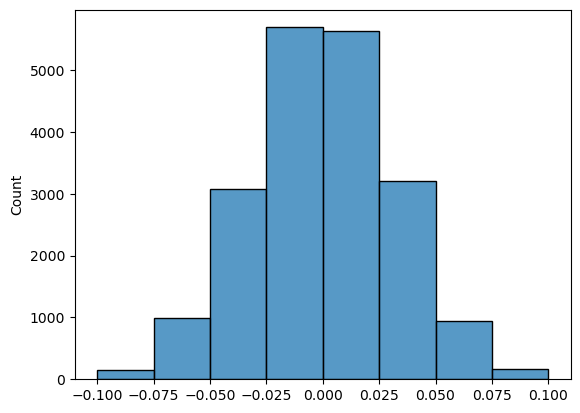

In [6]:
sns.histplot(rho[tril_mask==1], binrange=(-0.1, 0.1), binwidth=0.025)

<Axes: >

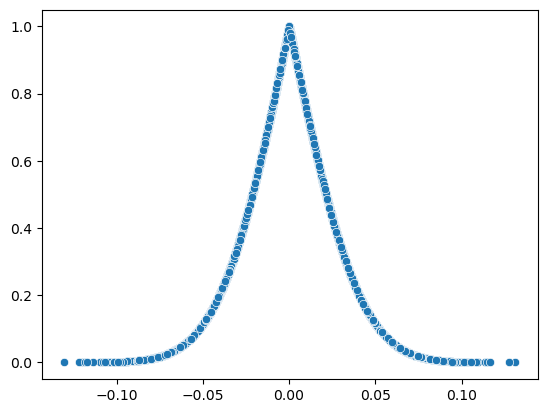

In [7]:
sns.scatterplot(x=rho[tril_mask==1], y=p[tril_mask==1])

In [8]:
(p[tril_mask==1]<0.05).mean()

0.049949748743718596